# Fixed Effect Panel Regression: Provincial Poverty Determinants in Indonesia

This notebook estimates panel regression models to analyze relationships between socioeconomic indicators and provincial poverty rates in Indonesia. The selected inferential model is Fixed Effects with robust standard errors.

In [7]:
import plotly.express as px
import plotly.graph_objects as go

## Library Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data_bps_datmin.csv'
OUTPUT_DIR = Path('panel_output')
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13

print('All libraries were imported successfully.')
import linearmodels
print(f'linearmodels version: {linearmodels.__version__}')
print(f'statsmodels version: {sm.__version__}')


All libraries were imported successfully.
linearmodels version: 7.0
statsmodels version: 0.14.5


## Data Loading and Exploration

In [9]:
df_raw = pd.read_csv(DATA_PATH)
df_raw.columns = [
    'province', 'year', 'aps_1315', 'aps_1618', 'aps_1924',
    'tpt_feb', 'tpt_aug', 'tpak_feb', 'tpak_aug',
    'poverty_line_march', 'poverty_line_september',
    'poor_population_march', 'poor_population_september',
    'poverty_pct_march', 'poverty_pct_september',
    'hdi', 'mean_years_schooling', 'expected_years_schooling'
]

print('Dataset Information')
print(f'Shape: {df_raw.shape}')
print(f'Provinces: {df_raw["province"].nunique()}')
print(f'Years: {sorted(df_raw["year"].unique())}')
print()
df_raw.head()


Dataset Information
Shape: (151, 18)
Provinces: 38
Years: [2021, 2022, 2023, 2024]



,province,year,aps_1315,aps_1618,aps_1924,tpt_feb,tpt_aug,tpak_feb,tpak_aug,poverty_line_march,poverty_line_september,poor_population_march,poor_population_september,poverty_pct_march,poverty_pct_september,hdi,mean_years_schooling,expected_years_schooling
0,SUMATERA UTARA,2021,96.99,78.66,27.05,6.01,6.33,69.39,69.10,525756,648336,1343.86,1110.92,9.01,7.19,73.84,9.88,13.27
1,SUMATERA BARAT,2021,96.63,84.07,36.41,6.67,6.52,68.41,67.72,568703,714991,370.67,315.43,6.63,5.42,74.56,9.46,14.09
2,RIAU,2021,95.66,77.81,28.79,4.96,4.42,65.81,65.03,565937,702620,500.81,473.04,7.12,6.36,73.89,9.52,13.28
3,JAMBI,2021,96.39,72.50,24.14,4.76,5.09,67.30,67.17,506355,658100,293.86,272.70,8.09,7.26,72.62,9.03,13.04
4,SUMATERA SELATAN,2021,94.85,71.53,18.81,5.17,4.98,69.95,68.77,457455,564462,1113.76,948.84,12.84,10.51,71.83,8.78,12.54


In [10]:
print('Descriptive Statistics')
print(df_raw.describe().to_string())


Descriptive Statistics
              year    aps_1315    aps_1618    aps_1924     tpt_feb     tpt_aug    tpak_feb    tpak_aug  poverty_line_march  poverty_line_september  poor_population_march  poor_population_september  poverty_pct_march  poverty_pct_september         hdi  mean_years_schooling  expected_years_schooling
count   151.000000  151.000000  151.000000  151.000000  151.000000  151.000000  151.000000  151.000000        1.510000e+02              151.000000             151.000000                 151.000000         151.000000             151.000000  151.000000            151.000000                151.000000
mean   2022.509934   94.392318   74.570331   27.616159    4.952848    4.764834   69.486623   69.577219        5.838603e+05           652458.443709             747.771126                 626.132715          11.704901              10.651656   72.264106              9.119536                 13.133046
std       1.118735    5.109407    6.389758    6.132170    1.523588    1.614804  

## Data Preprocessing and Feature Engineering

In [11]:
df = df_raw.copy()

df.columns = [
    'province', 'year', 'aps_1315', 'aps_1618', 'aps_1924',
    'tpt_feb', 'tpt_aug', 'tpak_feb', 'tpak_aug',
    'poverty_line_march', 'poverty_line_september',
    'poor_population_march', 'poor_population_september',
    'poverty_pct_march', 'poverty_pct_september',
    'hdi', 'mean_years_schooling', 'expected_years_schooling'
]

df['poverty_rate'] = (df['poverty_pct_march'] + df['poverty_pct_september']) / 2

df['tpt'] = (df['tpt_feb'] + df['tpt_aug']) / 2
df['tpak'] = (df['tpak_feb'] + df['tpak_aug']) / 2
df['poverty_line'] = (df['poverty_line_march'] + df['poverty_line_september']) / 2

df['log_poverty_line'] = np.log(df['poverty_line'])

df['province'] = df['province'].str.strip().str.upper()

print('Missing Values')
print(df.isnull().sum()[df.isnull().sum() > 0])
if df.isnull().sum().sum() == 0:
    print('No missing values.')

print(f'\nFinal shape: {df.shape}')
print()
print('Variables used:')
print('  poverty_rate : average poverty rate (March + September) / 2')
print('  ipm          : Human Development Index')
print('  tpt          : average open unemployment rate')
print('  tpak         : average labor force participation rate')
print('  aps_1315     : school participation rate ages 13-15')
print('  rls          : Mean Years of Schooling')
print('  hls          : Expected Years of Schooling')
print('  log_poverty_line       : natural log of average poverty line')


Missing Values
Series([], dtype: int64)
No missing values.

Final shape: (151, 23)

Variables used:
  poverty_rate : average poverty rate (March + September) / 2
  ipm          : Human Development Index
  tpt          : average open unemployment rate
  tpak         : average labor force participation rate
  aps_1315     : school participation rate ages 13-15
  rls          : Mean Years of Schooling
  hls          : Expected Years of Schooling
  log_poverty_line       : natural log of average poverty line


In [12]:
cols_to_corr = ['poverty_rate', 'hdi', 'tpt', 'tpak', 'aps_1315', 'mean_years_schooling', 'expected_years_schooling', 'log_poverty_line']
corr_matrix = df[cols_to_corr].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
corr_masked = corr_matrix.copy()
corr_masked.values[mask] = np.nan
fig_corr = px.imshow(corr_masked, text_auto=".3f", aspect="auto", color_continuous_scale="RdBu_r", zmin=-1, zmax=1)
fig_corr.update_layout(title="Panel Variable Correlation Matrix", height=800, width=800)
fig_corr.write_json(OUTPUT_DIR / 'plot_panel_correlation.json')
fig_corr.show()

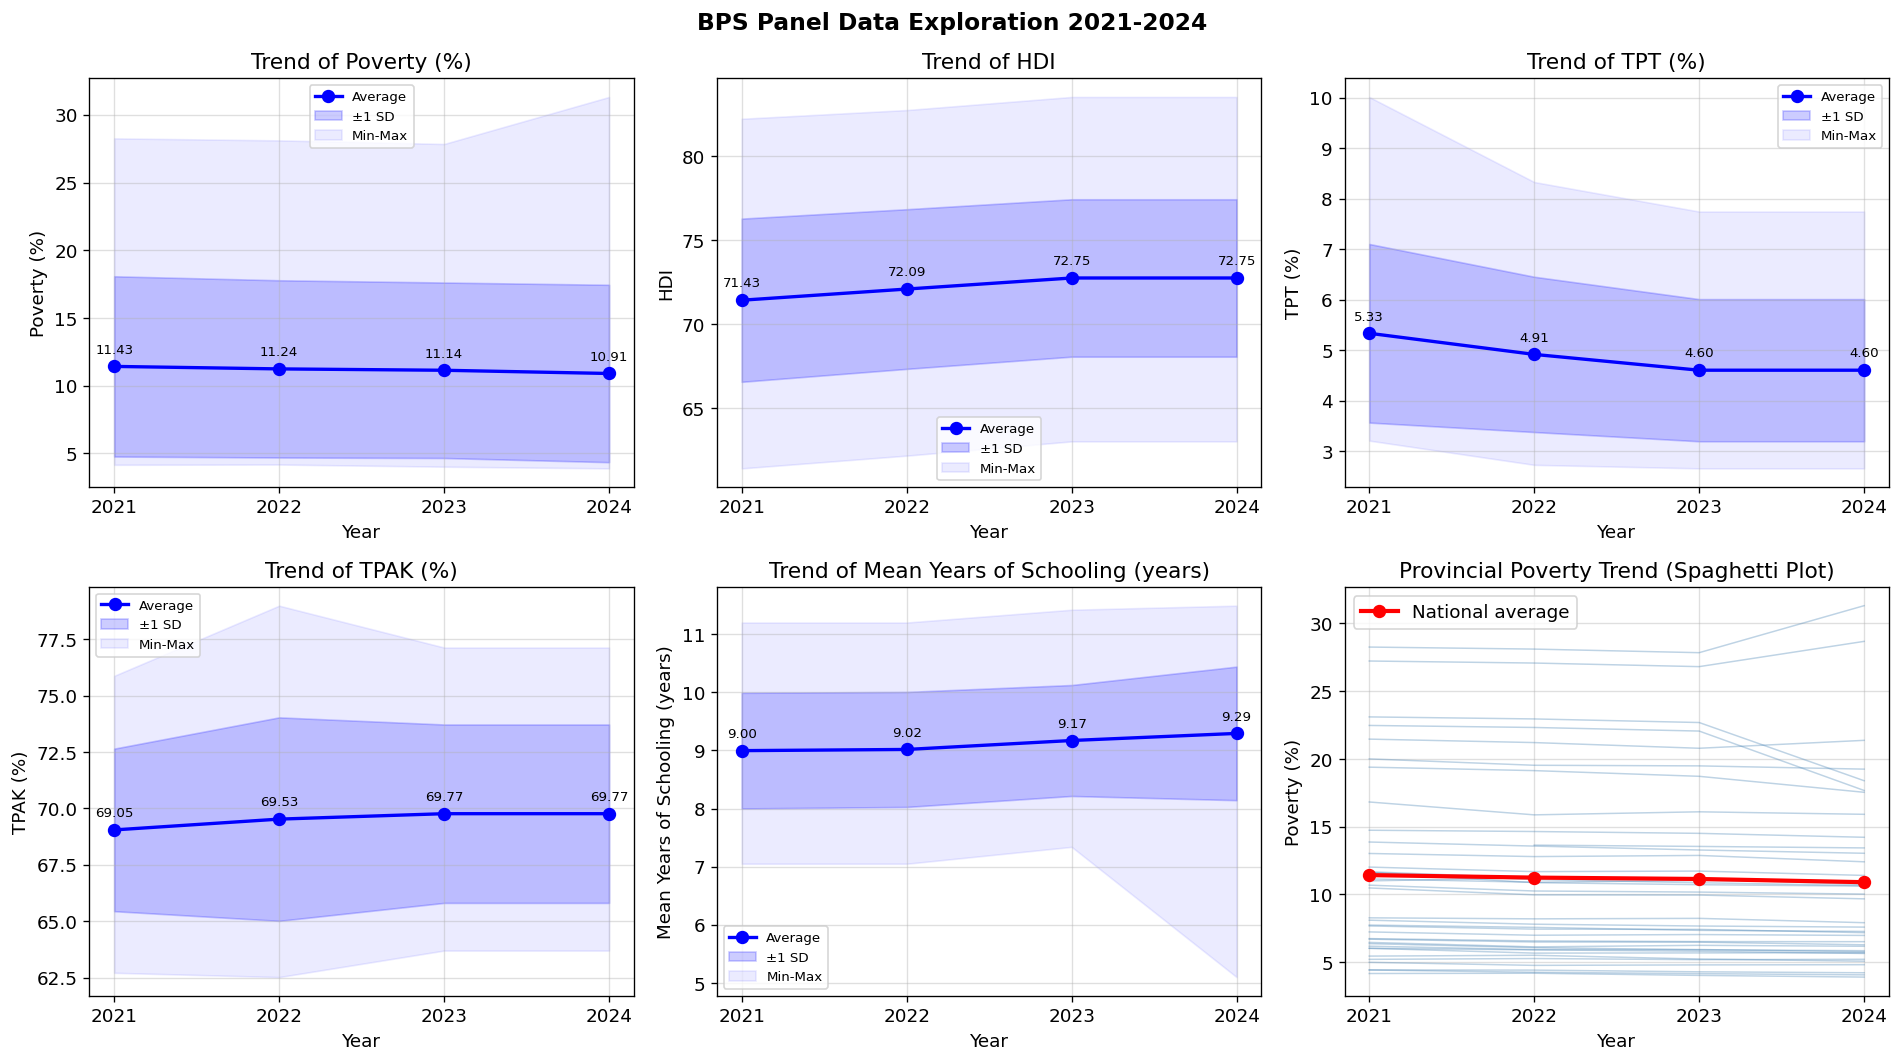

In [13]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

vars_plot = ['poverty_rate', 'hdi', 'tpt', 'tpak', 'mean_years_schooling']
var_labels = {'poverty_rate': 'Poverty (%)', 'hdi': 'HDI', 'tpt': 'TPT (%)', 'tpak': 'TPAK (%)', 'mean_years_schooling': 'Mean Years of Schooling (years)'}

fig_trends = make_subplots(rows=2, cols=3, subplot_titles=[f'Trend of {var_labels[v]}' for v in vars_plot] + ['Provincial Poverty Trend'])

years = sorted(df['year'].unique())

for idx, var in enumerate(vars_plot):
    row_idx = (idx // 3) + 1
    col_idx = (idx % 3) + 1
    grouped = df.groupby('year')[var].agg(['mean', 'std', 'min', 'max'])
    fig_trends.add_trace(go.Scatter(x=grouped.index, y=grouped['mean'], mode='lines+markers', name='Avg '+var, showlegend=False), row=row_idx, col=col_idx)

# 6th plot: Spaghetti
for prov in df['province'].unique():
    sub = df[df['province'] == prov].sort_values('year')
    fig_trends.add_trace(go.Scatter(x=sub['year'], y=sub['poverty_rate'], mode='lines', line=dict(color='steelblue', width=1), opacity=0.3, showlegend=False), row=2, col=3)

mean_trend = df.groupby('year')['poverty_rate'].mean()
fig_trends.add_trace(go.Scatter(x=mean_trend.index, y=mean_trend.values, mode='lines+markers', line=dict(color='red', width=3), name='National Avg', showlegend=False), row=2, col=3)

fig_trends.update_layout(height=800, width=1300, title_text='BPS Panel Data Exploration 2021-2024')
fig_trends.write_json(OUTPUT_DIR / 'plot_panel_trends.json')
fig_trends.show()


In [14]:
print('Variation Decomposition (Between vs Within)')
print(f'{"Variable":35s} {"Total SD":>10s} {"Between SD":>12s} {"Within SD":>11s} {"Within/Total":>13s}')
print('-' * 83)

for var in ['poverty_rate', 'hdi', 'tpt', 'tpak', 'mean_years_schooling', 'expected_years_schooling', 'log_poverty_line', 'aps_1315']:
    total_sd = df[var].std()

    prov_mean = df.groupby('province')[var].mean()
    between_sd = prov_mean.std()

    df_temp = df.copy()
    df_temp['prov_mean'] = df_temp.groupby('province')[var].transform('mean')
    within_sd = (df_temp[var] - df_temp['prov_mean']).std()

    ratio = within_sd / total_sd if total_sd > 0 else 0
    print(f'{var:35s} {total_sd:>10.4f} {between_sd:>12.4f} {within_sd:>11.4f} {ratio:>12.2%}')


Variation Decomposition (Between vs Within)
Variable                              Total SD   Between SD   Within SD  Within/Total
-----------------------------------------------------------------------------------
poverty_rate                            6.4910       6.5120      0.5734        8.83%
hdi                                     4.7377       4.7428      0.5340       11.27%
tpt                                     1.5506       1.5147      0.3853       24.85%
tpak                                    3.9918       3.9573      0.8038       20.14%
mean_years_schooling                    1.0218       0.9709      0.3430       33.57%
expected_years_schooling                0.8836       0.8419      0.3027       34.26%
log_poverty_line                        0.1901       0.1870      0.0410       21.55%
aps_1315                                5.1094       5.1449      0.2561        5.01%


## Panel Data Setup

The `linearmodels` package requires a MultiIndex structure with province as the entity index and year as the time index.

In [15]:
VARS_MODEL = ['province', 'year', 'poverty_rate', 'hdi', 'tpt', 'tpak', 'aps_1315', 'mean_years_schooling', 'expected_years_schooling', 'log_poverty_line']
df_panel = df[VARS_MODEL].copy()

df_panel = df_panel.set_index(['province', 'year'])

print('Panel Data (MultiIndex)')
print(f'Shape: {df_panel.shape}')
print(f'Level 0 (Province): {df_panel.index.get_level_values(0).nunique()} unit')
print(f'Level 1 (Year): {df_panel.index.get_level_values(1).nunique()} periode')
print(f'Total observations: {len(df_panel)}')
print()

counts = df_panel.groupby(level=0).size()
print(f'Panel balanced? {counts.nunique() == 1}')
print(f'Observations by province: min={counts.min()}, max={counts.max()}, unique={counts.unique()}')
print()
print(df_panel.head(8))


Panel Data (MultiIndex)
Shape: (151, 8)
Level 0 (Province): 38 unit
Level 1 (Year): 4 periode
Total observations: 151

Panel balanced? False
Observations by province: min=3, max=4, unique=[3 4]

                           poverty_rate    hdi    tpt    tpak  aps_1315  \
province             year                                                 
SUMATERA UTARA       2021         8.100  73.84  6.170  69.245     96.99   
SUMATERA BARAT       2021         6.025  74.56  6.595  68.065     96.63   
RIAU                 2021         6.740  73.89  4.690  65.420     95.66   
JAMBI                2021         7.675  72.62  4.925  67.235     96.39   
SUMATERA SELATAN     2021        11.675  71.83  5.075  69.360     94.85   
BENGKULU             2021        13.870  73.16  3.685  70.745     97.49   
LAMPUNG              2021        11.620  71.25  4.615  70.540     95.58   
KEP. BANGKA BELITUNG 2021         4.990  72.96  5.035  66.935     93.17   

                           mean_years_schooling  expec

## Multicollinearity Check

Variance Inflation Factor (VIF)
VIF > 10 indicates serious multicollinearity
                Variable      VIF
                aps_1315 4.182473
    mean_years_schooling 3.865732
expected_years_schooling 3.272484
                     hdi 2.942514
                    tpak 2.290628
                     tpt 2.187028
        log_poverty_line 1.278245


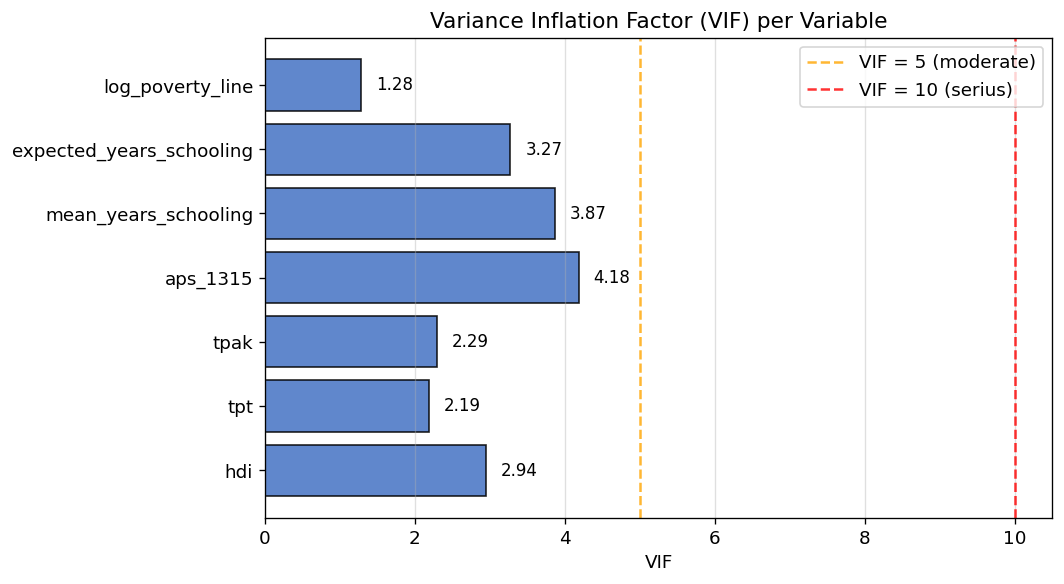


All variables are below the critical VIF threshold.


In [16]:
colors_vif = ['#C00000' if v > 10 else '#FF7F00' if v > 5 else '#4472C4' for v in vif_data['VIF']]
fig_vif = px.bar(vif_data, x='VIF', y='Variable', orientation='h', color='Variable', color_discrete_sequence=colors_vif)
fig_vif.add_vline(x=5, line_dash="dash", line_color="orange", annotation_text="VIF = 5")
fig_vif.add_vline(x=10, line_dash="dash", line_color="red", annotation_text="VIF = 10")
fig_vif.update_layout(title="Variance Inflation Factor (VIF) per Variable", height=500, width=800, showlegend=False)
fig_vif.write_json(OUTPUT_DIR / 'plot_panel_vif.json')
fig_vif.show()

high_vif = vif_data[vif_data['VIF'] > 10]['Variable'].tolist()
if high_vif:
    print(f'\nVariable dengan VIF > 10: {high_vif}')
    print('Pertimbangkan untuk mengeluarkan atau menggabungkan variable tersebut.')
else:
    print('\nAll variables are below the critical VIF threshold.')


In [17]:

FORMULA_FULL = 'poverty_rate ~ ipm + tpt + tpak + aps_1315 + rls + hls + log_poverty_line'

FORMULA_PARSI = 'poverty_rate ~ ipm + tpt + tpak + log_poverty_line'

print('Model to be estimated:')
print(f'  Model Lenpoverty_lineap : {FORMULA_FULL}')
print(f'  Model Parsimoni: {FORMULA_PARSI}')


Model to be estimated:
  Model Lenpoverty_lineap : poverty_rate ~ ipm + tpt + tpak + aps_1315 + rls + hls + log_poverty_line
  Model Parsimoni: poverty_rate ~ ipm + tpt + tpak + log_poverty_line


## Panel Model Estimation

The notebook estimates Pooled OLS, entity Fixed Effects, two-way Fixed Effects, and Random Effects models before selecting the final specification.

In [18]:
exog_vars = ['hdi', 'tpt', 'tpak', 'aps_1315', 'mean_years_schooling', 'expected_years_schooling', 'log_poverty_line']

exog = sm.add_constant(df_panel[exog_vars])
endog = df_panel['poverty_rate']

mod_pooled = PooledOLS(endog, exog)
res_pooled = mod_pooled.fit(cov_type='robust')

print('POOLED OLS (Robust SE)')
print(res_pooled.summary)


POOLED OLS (Robust SE)
                          PooledOLS Estimation Summary                          
Dep. Variable:           poverty_rate   R-squared:                        0.7392
Estimator:                  PooledOLS   R-squared (Between):              0.7595
No. Observations:                 151   R-squared (Within):              -2.1553
Date:                Sat, May 23 2026   R-squared (Overall):              0.7392
Time:                        05:43:59   Log-likelihood                   -394.71
Cov. Estimator:                Robust                                           
                                        F-statistic:                      57.909
Entities:                          38   P-value                           0.0000
Avg Obs:                       3.9737   Distribution:                   F(7,143)
Min Obs:                       3.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             35.767
     

In [19]:
mod_fe = PanelOLS(endog, exog, entity_effects=True, time_effects=False)
res_fe = mod_fe.fit(cov_type='robust')

print('FIXED EFFECTS - Entity Effects (Robust SE)')
print(res_fe.summary)


FIXED EFFECTS - Entity Effects (Robust SE)
                          PanelOLS Estimation Summary                           
Dep. Variable:           poverty_rate   R-squared:                        0.8890
Estimator:                   PanelOLS   R-squared (Between):              0.5433
No. Observations:                 151   R-squared (Within):               0.8890
Date:                Sat, May 23 2026   R-squared (Overall):              0.5487
Time:                        05:43:59   Log-likelihood                    36.183
Cov. Estimator:                Robust                                           
                                        F-statistic:                      121.29
Entities:                          38   P-value                           0.0000
Avg Obs:                       3.9737   Distribution:                   F(7,106)
Min Obs:                       3.0000                                           
Max Obs:                       4.0000   F-statistic (robust):     

In [20]:
mod_fe2 = PanelOLS(endog, exog, entity_effects=True, time_effects=True)
res_fe2 = mod_fe2.fit(cov_type='robust')

print('FIXED EFFECTS - Two-Way (Entity + Time, Robust SE)')
print(res_fe2.summary)


FIXED EFFECTS - Two-Way (Entity + Time, Robust SE)
                          PanelOLS Estimation Summary                           
Dep. Variable:           poverty_rate   R-squared:                        0.9156
Estimator:                   PanelOLS   R-squared (Between):              0.2761
No. Observations:                 151   R-squared (Within):               0.3244
Date:                Sat, May 23 2026   R-squared (Overall):              0.2776
Time:                        05:43:59   Log-likelihood                    67.834
Cov. Estimator:                Robust                                           
                                        F-statistic:                      159.71
Entities:                          38   P-value                           0.0000
Avg Obs:                       3.9737   Distribution:                   F(7,103)
Min Obs:                       3.0000                                           
Max Obs:                       4.0000   F-statistic (robus

In [21]:
mod_re = RandomEffects(endog, exog)
res_re = mod_re.fit(cov_type='robust')

print('RANDOM EFFECTS (Robust SE)')
print(res_re.summary)


RANDOM EFFECTS (Robust SE)
                        RandomEffects Estimation Summary                        
Dep. Variable:           poverty_rate   R-squared:                        0.8528
Estimator:              RandomEffects   R-squared (Between):              0.6101
No. Observations:                 151   R-squared (Within):               0.8859
Date:                Sat, May 23 2026   R-squared (Overall):              0.6157
Time:                        05:43:59   Log-likelihood                    5.0980
Cov. Estimator:                Robust                                           
                                        F-statistic:                      118.31
Entities:                          38   P-value                           0.0000
Avg Obs:                       3.9737   Distribution:                   F(7,143)
Min Obs:                       3.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             63.941
 

## Hausman Test: Fixed Effects vs Random Effects

The Hausman test evaluates whether Random Effects is consistent or whether Fixed Effects is preferred due to correlation between individual effects and regressors.

In [22]:

common_vars = [v for v in exog_vars if v in res_fe.params.index and v in res_re.params.index]

b_fe = res_fe.params[common_vars]
b_re = res_re.params[common_vars]
diff = b_fe - b_re

V_fe = res_fe.cov.loc[common_vars, common_vars]
V_re = res_re.cov.loc[common_vars, common_vars]
V_diff = V_fe - V_re

try:
    V_diff_inv = np.linalg.pinv(V_diff.values)
    H_stat = float(diff.values @ V_diff_inv @ diff.values)
    df_h = len(common_vars)
    p_hausman = 1 - stats.chi2.cdf(H_stat, df_h)

    print('HAUSMAN TEST')
    print(f'H statistic   : {H_stat:.4f}')
    print(f'Degrees of freedom: {df_h}')
    print(f'p-value       : {p_hausman:.4f}')
    print()
    if p_hausman < 0.05:
        print('Decision: REJECT H0 (p < 0.05)')
        print('Rekomendasi: Gunakan FIXED EFFECTS')
        print('Interpretation: There is correlation between individual effects and regressors.')
    else:
        print('Decision: FAIL TO REJECT H0 (p >= 0.05)')
        print('Rekomendasi: Gunakan RANDOM EFFECTS (lebih efisien)')
        print('Interpretation: There is no significant correlation between individual effects and regressors.')
except Exception as e:
    print(f'Hausman test error: {e}')
    print('Use theoretical judgment: Fixed Effects is generally more conservative for provincial panel data.')


HAUSMAN TEST
H statistic   : 31.5833
Degrees of freedom: 7
p-value       : 0.0000

Decision: REJECT H0 (p < 0.05)
Rekomendasi: Gunakan FIXED EFFECTS
Interpretation: There is correlation between individual effects and regressors.


In [23]:
print('INDIVIDUAL EFFECTS F-TEST (FE vs Pooled OLS)')
print('H0: There is no efek individu (Pooled OLS is sufficient)')
print('H1: There is efek individu significant (Fixed Effects is required)')
print()

print(f'F-statistic hasil FE model: {res_fe.f_statistic.stat:.4f}')
print(f'p-value F-stat: {res_fe.f_statistic.pval:.6f}')
if res_fe.f_statistic.pval < 0.05:
    print('Decision: REJECT H0: Fixed Effects significant diperlukan.')
else:
    print('Decision: FAIL TO REJECT H0: Pooled OLS munpoverty_linein mencukupi.')


INDIVIDUAL EFFECTS F-TEST (FE vs Pooled OLS)
H0: There is no efek individu (Pooled OLS is sufficient)
H1: There is efek individu significant (Fixed Effects is required)

F-statistic hasil FE model: 121.2889
p-value F-stat: 0.000000
Decision: REJECT H0: Fixed Effects significant diperlukan.


## Fixed Effects Interpretation

In [24]:
y_hat_fe = res_fe.fitted_values
residuals_fe = res_fe.resids

df_work = df_panel.copy()
df_work['fitted'] = y_hat_fe
df_work['resid'] = residuals_fe

prov_effects = df_work.groupby(level=0)['resid'].mean().sort_values()

print('Individual Fixed Effects by Province')
print('Positive values indicate provinces with poverty rates above the model prediction')
print('Negative values indicate provinces with poverty rates below the model prediction')
print()
print(prov_effects.round(4).to_string())


Individual Fixed Effects by Province
Positive values indicate provinces with poverty rates above the model prediction
Negative values indicate provinces with poverty rates below the model prediction

province
MALUKU                 -0.0
KALIMANTAN BARAT       -0.0
KALIMANTAN SELATAN     -0.0
SULAWESI BARAT         -0.0
SUMATERA UTARA         -0.0
GORONTALO              -0.0
RIAU                   -0.0
SUMATERA BARAT         -0.0
KALIMANTAN TIMUR       -0.0
SULAWESI TENGGARA      -0.0
DKI JAKARTA            -0.0
JAWA BARAT             -0.0
PAPUA PEGUNUNGAN       -0.0
BALI                   -0.0
KALIMANTAN TENGAH      -0.0
NUSA TENGGARA TIMUR    -0.0
JAWA TENGAH            -0.0
NUSA TENGGARA BARAT    -0.0
PAPUA                  -0.0
LAMPUNG                -0.0
SULAWESI SELATAN       -0.0
JAMBI                  -0.0
MALUKU UTARA           -0.0
PAPUA BARAT            -0.0
SUMATERA SELATAN       -0.0
KEP. BANGKA BELITUNG   -0.0
SULAWESI TENGAH        -0.0
PAPUA TENGAH           -0.0
JAWA TI

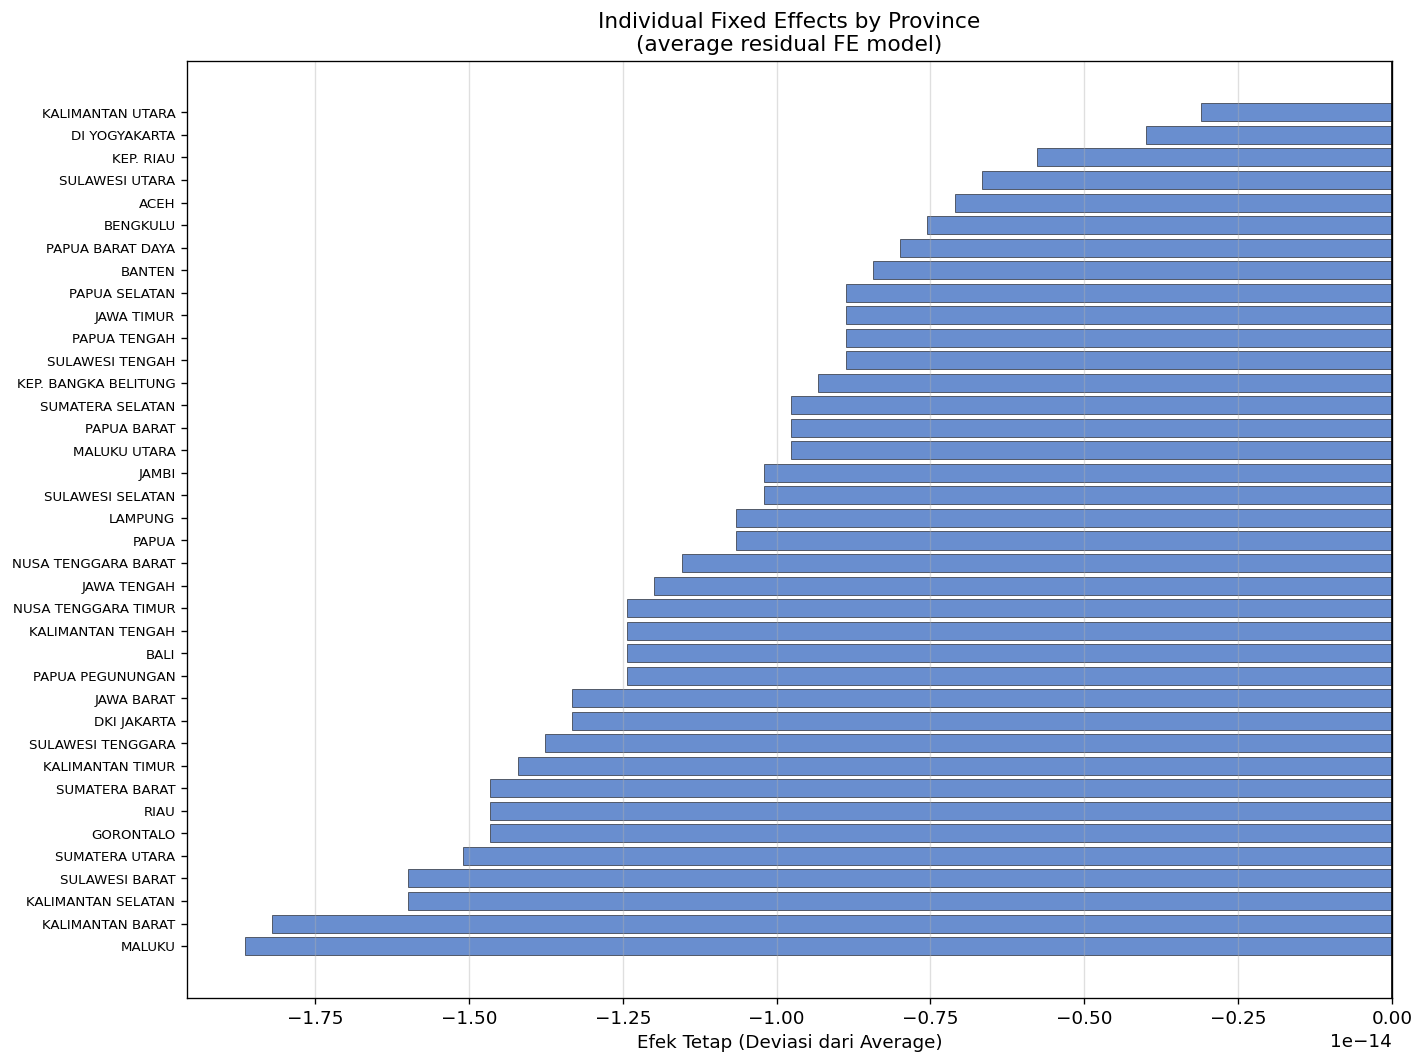

In [25]:
colors_fe = ['#C00000' if v > 0 else '#4472C4' for v in prov_effects.values]
fig_fe = go.Figure(go.Bar(x=prov_effects.values, y=prov_effects.index, orientation='h', marker_color=colors_fe))
fig_fe.add_vline(x=0, line_width=1, line_color="black")
fig_fe.update_layout(title='Individual Fixed Effects by Province', xaxis_title='Efek Tetap (Deviasi dari Average)', height=800, width=900)
fig_fe.write_json(OUTPUT_DIR / 'plot_panel_fe_effects.json')
fig_fe.show()


In [26]:
models = {
    'Pooled OLS': res_pooled,
    'Fixed Effects': res_fe,
    'FE Two-Way': res_fe2,
    'Random Effects': res_re
}

print('MODEL COEFFICIENT COMPARISON')
print(f'{"Variable":15s}', end='')
for name in models:
    print(f'{name:>18s}', end='')
print()
print('-' * (15 + 18 * len(models)))

for var in exog_vars + ['const']:
    print(f'{var:15s}', end='')
    for name, res in models.items():
        if var in res.params:
            coef = res.params[var]
            pval = res.pvalues[var]
            stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.1 else ''
            print(f'{coef:>12.4f}{stars:>6s}', end='')
        else:
            print(f'{"N/A":>18s}', end='')
    print()

print()
print('Significantsi: *** p<0.01, ** p<0.05, * p<0.1')
print()

print('GOODNESS OF FIT')
print(f'{"Metrik":20s}', end='')
for name in models:
    print(f'{name:>18s}', end='')
print()
print('-' * (20 + 18 * len(models)))

metrics = {
    'R-squared': lambda r: getattr(r, 'rsquared', getattr(r, 'rsquared_between', np.nan)),
    'R-sq Within': lambda r: getattr(r, 'rsquared_within', np.nan),
    'R-sq Between': lambda r: getattr(r, 'rsquared_between', np.nan),
}

for metric_name, metric_fn in metrics.items():
    print(f'{metric_name:20s}', end='')
    for res in models.values():
        try:
            val = metric_fn(res)
            print(f'{val:>18.4f}', end='')
        except:
            print(f'{"N/A":>18s}', end='')
    print()


MODEL COEFFICIENT COMPARISON
Variable               Pooled OLS     Fixed Effects        FE Two-Way    Random Effects
---------------------------------------------------------------------------------------
hdi                 -1.0891   ***     -0.4362   ***     -0.0431           -0.5778   ***
tpt                  0.6527   ***     -0.0648           -0.1627   ***     -0.1217    **
tpak                 0.4467   ***      0.0201            0.0353            0.0406     *
aps_1315            -0.1928           -0.0328           -0.0424           -0.0771      
mean_years_schooling     -0.0981           -1.3656   ***     -1.2251   ***     -1.3337   ***
expected_years_schooling      2.1611   ***     -0.0134            0.0530            0.0145      
log_poverty_line      3.2295     *      4.3292    **      8.8198   ***      5.3968   ***
const                3.3595           -0.3063          -90.3438    **     -1.8812      

Significantsi: *** p<0.01, ** p<0.05, * p<0.1

GOODNESS OF FIT
Metrik      

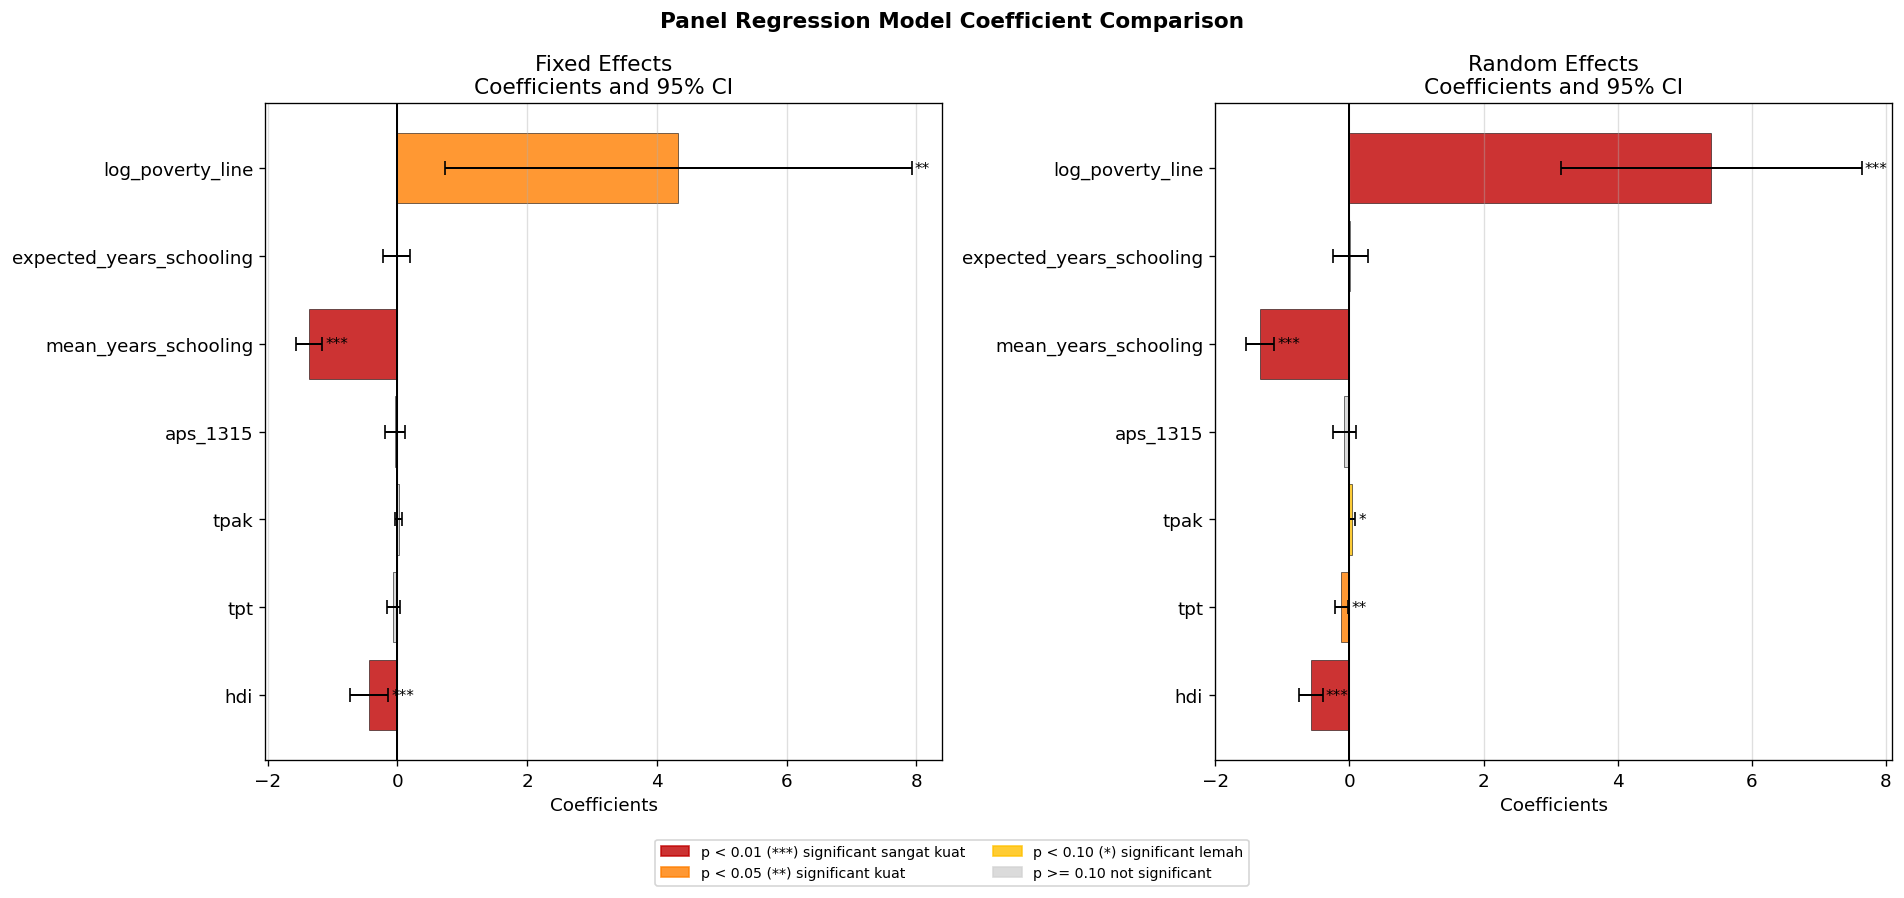

In [27]:
fig_coefs = make_subplots(rows=1, cols=2, subplot_titles=('Fixed Effects', 'Random Effects'))

model_pairs = [('Fixed Effects', res_fe), ('Random Effects', res_re)]

for idx, (model_name, res) in enumerate(model_pairs):
    vars_plot = [v for v in exog_vars if v in res.params.index]
    coefs = res.params[vars_plot]
    se = res.std_errors[vars_plot]
    pvals = res.pvalues[vars_plot]

    colors_coef = ['#C00000' if p < 0.01 else '#FF7F00' if p < 0.05 else '#FFC000' if p < 0.1 else '#D3D3D3' for p in pvals]
    
    fig_coefs.add_trace(go.Bar(x=coefs.values, y=vars_plot, orientation='h', marker_color=colors_coef, error_x=dict(type='data', array=1.96*se.values), showlegend=False), row=1, col=idx+1)
    
fig_coefs.update_layout(title='Panel Regression Model Coefficient Comparison', height=600, width=1200)
fig_coefs.write_json(OUTPUT_DIR / 'plot_panel_coefs.json')
fig_coefs.show()


## Residual Diagnostics

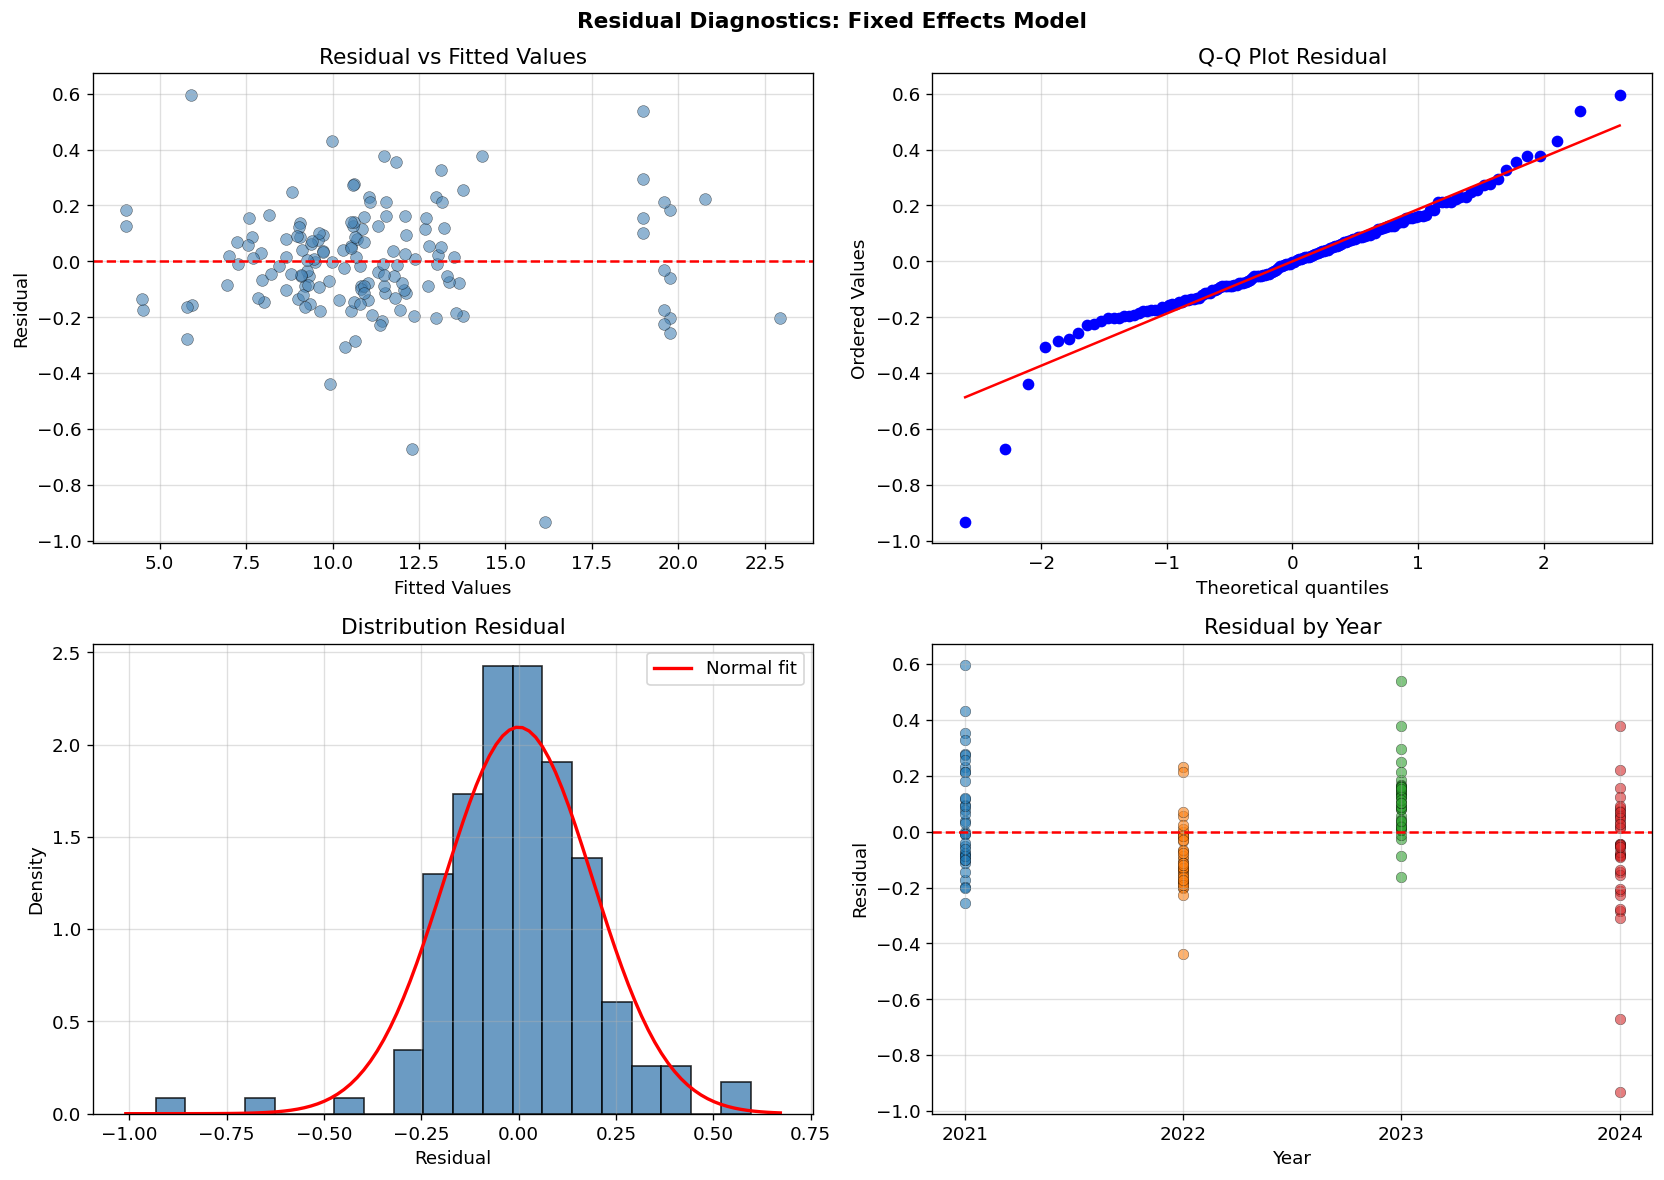

RESIDUAL DIAGNOSTIC TESTS
Shapiro-Wilk test  : W = 0.9419, p = 0.0000
  Interpretation: Residuals are not normally distributed
Durbin-Watson stat : 1.8648
  Interpretation: No autocorrelation
Mean residual      : -0.000000
Std residual       : 0.1904


In [28]:
fig_diag = make_subplots(rows=2, cols=2, subplot_titles=('Residual vs Fitted Values', 'Q-Q Plot Residual', 'Distribution Residual', 'Residual by Year'))

# 1
fig_diag.add_trace(go.Scatter(x=fitted_fe, y=resid_fe, mode='markers', marker=dict(color='steelblue'), showlegend=False), row=1, col=1)
fig_diag.add_hline(y=0, line_dash="dash", line_color="red", row=1, col=1)

# 3
fig_diag.add_trace(go.Histogram(x=resid_fe, marker_color='steelblue', showlegend=False), row=2, col=1)

# 4
year_idx = df_panel.index.get_level_values(1)
fig_diag.add_trace(go.Scatter(x=year_idx, y=resid_fe, mode='markers', marker=dict(color='steelblue'), showlegend=False), row=2, col=2)
fig_diag.add_hline(y=0, line_dash="dash", line_color="red", row=2, col=2)

fig_diag.update_layout(title='Residual Diagnostics: Fixed Effects Model', height=800, width=1100)
fig_diag.write_json(OUTPUT_DIR / 'plot_panel_diagnostics.json')
fig_diag.show()

stat_sw, p_sw = stats.shapiro(resid_fe)
dw_stat = durbin_watson(resid_fe)

print('RESIDUAL DIAGNOSTIC TESTS')
print(f'Shapiro-Wilk test  : W = {stat_sw:.4f}, p = {p_sw:.4f}')
print(f'Durbin-Watson stat : {dw_stat:.4f}')
print(f'Mean residual      : {resid_fe.mean():.6f}')
print(f'Std residual       : {resid_fe.std():.4f}')


## Save Output Files

In [29]:
coef_rows = []
for var in res_fe.params.index:
    coef_rows.append({
        'variable': var,
        'coefficient': res_fe.params[var],
        'std_error': res_fe.std_errors[var],
        't_stat': res_fe.tstats[var],
        'p_value': res_fe.pvalues[var],
        'ci_lower': res_fe.params[var] - 1.96 * res_fe.std_errors[var],
        'ci_upper': res_fe.params[var] + 1.96 * res_fe.std_errors[var],
        'significant': res_fe.pvalues[var] < 0.05
    })

df_coef = pd.DataFrame(coef_rows)
df_coef.to_csv(OUTPUT_DIR / 'output_fe_coefficient.csv', index=False)
print('Saved: output_fe_coefficient.csv')
print(df_coef.round(4).to_string(index=False))
print()

df_fitted = df_panel[['poverty_rate']].copy()
df_fitted['fitted_pooled'] = res_pooled.fitted_values
df_fitted['fitted_fe'] = res_fe.fitted_values
df_fitted['fitted_re'] = res_re.fitted_values
df_fitted['resid_fe'] = res_fe.resids
df_fitted = df_fitted.reset_index()

df_fitted.to_csv(OUTPUT_DIR / 'output_fe_fitted_residuals.csv', index=False)
print('Saved: output_fe_fitted_residuals.csv')
print(df_fitted.head(10).round(4).to_string(index=False))
print()

df_effects = prov_effects.reset_index()
df_effects.columns = ['province', 'fixed_effect']
df_effects = df_effects.sort_values('fixed_effect', ascending=False)
df_effects.to_csv(OUTPUT_DIR / 'output_fe_individual_effects.csv', index=False)
print('Saved: output_fe_individual_effects.csv')
print(df_effects.round(4).to_string(index=False))


Saved: output_fe_coefficient.csv
                variable  coefficient  std_error   t_stat  p_value  ci_lower  ci_upper  significant
                   const      -0.3063    17.5140  -0.0175   0.9861  -34.6337   34.0212        False
                     hdi      -0.4362     0.1503  -2.9028   0.0045   -0.7307   -0.1417         True
                     tpt      -0.0648     0.0520  -1.2460   0.2155   -0.1668    0.0372        False
                    tpak       0.0201     0.0252   0.7997   0.4257   -0.0292    0.0695        False
                aps_1315      -0.0328     0.0795  -0.4130   0.6804   -0.1887    0.1230        False
    mean_years_schooling      -1.3656     0.1038 -13.1561   0.0000   -1.5690   -1.1622         True
expected_years_schooling      -0.0134     0.1061  -0.1267   0.8994   -0.2213    0.1944        False
        log_poverty_line       4.3292     1.8351   2.3591   0.0202    0.7323    7.9261         True

Saved: output_fe_fitted_residuals.csv
            province  year  

In [30]:
print('FIXED EFFECT PANEL REGRESSION SUMMARY')
print()
print(f'Selected model   : Fixed Effects (Entity)')
print(f'Number of provinces  : {df_panel.index.get_level_values(0).nunique()}')
print(f'Period          : {sorted(df_panel.index.get_level_values(1).unique())}')
print(f'Total observations  : {len(df_panel)}')
print()
print('Significant coefficients (p<0.05):')
sig_vars = df_coef[df_coef['significant']]
for _, r in sig_vars.iterrows():
    direction = 'positive' if r['coefficient'] > 0 else 'negative'
    print(f"  {r['variable']:15s}: coef = {r['coefficient']:.4f} ({direction}), p = {r['p_value']:.4f}")
print()
print('CSV Outputs:')
print('  1. output_fe_coefficient.csv          -> Fixed effects coefficients')
print('  2. output_fe_fitted_residuals.csv   -> Fitted values and residuals')
print('  3. output_fe_individual_effects.csv -> Fixed effects by province')


FIXED EFFECT PANEL REGRESSION SUMMARY

Selected model   : Fixed Effects (Entity)
Number of provinces  : 38
Period          : [2021, 2022, 2023, 2024]
Total observations  : 151

Significant coefficients (p<0.05):
  hdi            : coef = -0.4362 (negative), p = 0.0045
  mean_years_schooling: coef = -1.3656 (negative), p = 0.0000
  log_poverty_line: coef = 4.3292 (positive), p = 0.0202

CSV Outputs:
  1. output_fe_coefficient.csv          -> Fixed effects coefficients
  2. output_fe_fitted_residuals.csv   -> Fitted values and residuals
  3. output_fe_individual_effects.csv -> Fixed effects by province
